In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import argparse
import keras
import tensorflow as tf
from keras.models import Sequential, load_model, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization,Rescaling, Activation
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import image_dataset_from_directory,img_to_array, array_to_img, save_img
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image


In [2]:
path = "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog"
new_dir = ['cat', 'dog']

for i in new_dir:
    os.makedirs(os.path.join(path, i), exist_ok=True)

for element in os.listdir(path):
    full_path = os.path.join(path, element)
    
    if os.path.isfile(full_path):  # ← only process files, skip folders
        if element.startswith("dog"):
            os.rename(full_path, os.path.join(path, "dog", element))
        elif element.startswith("cat"):
            os.rename(full_path, os.path.join(path, "cat", element))

In [3]:
train_data = image_dataset_from_directory(
   "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog",
    labels="inferred",
    image_size=(128, 128),
    batch_size=32,
    color_mode="rgb",
    validation_split=0.2,
    subset="training",
    shuffle=True,
    seed=42,     
    format="tf"
)

val_data = image_dataset_from_directory(
   "C:/Users/Dell/PycharmProjects/Deep Learning/cat_dog",
    labels="inferred",
    image_size=(128, 128),
    batch_size=32,
    color_mode="rgb",
    validation_split=0.2,
    subset="validation",
    shuffle=True,
    seed=42,     
    format="tf"
)


Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


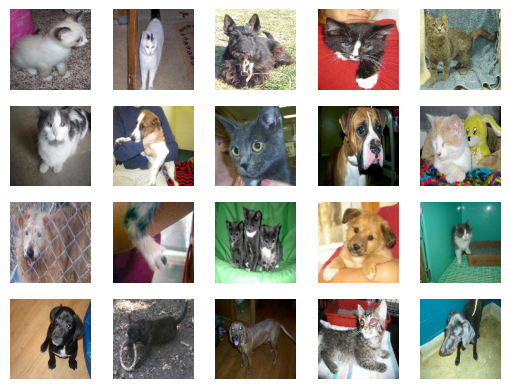

In [4]:
images, labels = next(iter(train_data))
for idx, i in enumerate(images[:20]):
    for j in labels[:20]:
        i = img_to_array(i)
        plt.subplot(4, 5, idx+1)
        plt.xlabel(j)
        plt.imshow(i.astype("uint8"))
        plt.axis("off") 

In [5]:
data_augmentation = Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

In [6]:
model = Sequential()
model.add(Rescaling(1./255, input_shape=(128, 128, 3)))
model.add(data_augmentation)
model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', name='conv2d_1'))
model.add(BatchNormalization(name='batch_norm_1'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_1'))

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', name='conv2d_2'))
model.add(BatchNormalization(name='batch_norm_2'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_2'))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2d_3'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_3'))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', name='conv2d_4'))
model.add(MaxPooling2D(pool_size=(2, 2), name='max_pooling_4'))

model.add(Flatten(name='flatten'))

model.add(Dense(64, activation='relu', name='dense_2'))
model.add(Dropout(0.3))
model.add(Dense(32,  activation='relu', name='Next_output_layer'))
model.add(Dropout(0.3))
#model.add(Dense(8,  activation='relu', name='Next_output_layer1'))
model.add(Dense(1, activation='sigmoid', name='output_layer'))

model.summary()

c:\Users\Dell\PycharmProjects\Azure ML\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_3 (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_4 (MaxPooling2D)    │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Next_output_layer (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,721 (1.51 MB)

 Trainable params: 394,625 (1.51 MB)

 Non-trainable params: 96 (384.00 B)

In [7]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(train_data, epochs=40, validation_data= val_data)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 612ms/step - accuracy: 0.6056 - loss: 0.6604 - val_accuracy: 0.6602 - val_loss: 0.6155
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 344s 551ms/step - accuracy: 0.6900 - loss: 0.5864 - val_accuracy: 0.7358 - val_loss: 0.5420
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 337s 538ms/step - accuracy: 0.7378 - loss: 0.5342 - val_accuracy: 0.7700 - val_loss: 0.4833
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 454s 726ms/step - accuracy: 0.7550 - loss: 0.5079 - val_accuracy: 0.7670 - val_loss: 0.4851
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 427s 605ms/step - accuracy: 0.7751 - loss: 0.4823 - val_accuracy: 0.7714 - val_loss: 0.4794
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 377s 602ms/step - accuracy: 0.7864 - loss: 0.4594 - val_accuracy: 0.7868 - val_loss: 0.4468
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 351s 561ms/step - accuracy: 0.7986 - loss: 0.4417 - val_accuracy: 0.8140 - val_loss: 0.4126
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 564ms/step - accuracy: 0.8042 -

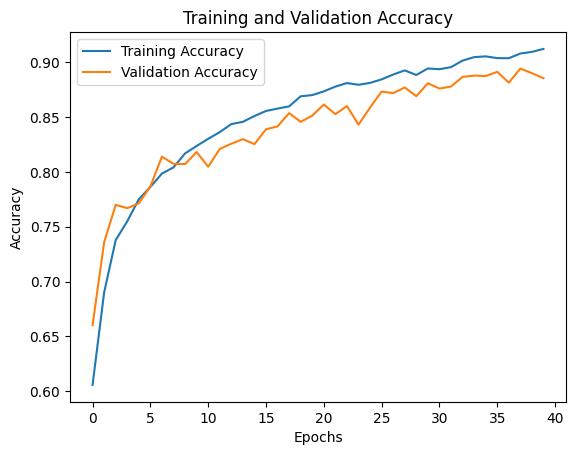

In [10]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

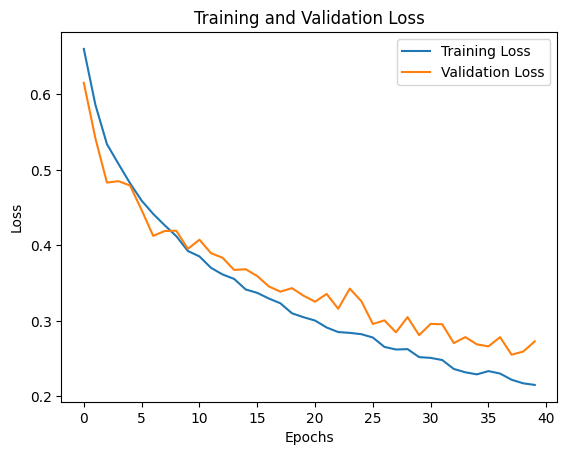

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history["val_loss"], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()    

In [12]:
model.save("cat_dog_model_D.keras")

In [34]:
img  = load_img('dog.2.jpg', target_size=(128, 128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
predictions = (model.predict(img_array) > 0.5).astype("int32")
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


array([[1]], dtype=int32)

In [33]:
img  = load_img('cat_4.jpg', target_size=(128, 128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)
predictions = (predictions>0.5).astype("int32")
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([[0]], dtype=int32)